In [5]:
import numpy as np
import math
import time
from connect4.connect_state import ConnectState
from connect4.policy import Policy
from connect4.utils import find_importable_classes
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 1. Función de partida 1v1
# ============================

def play_single_game(policy_first_class, policy_second_class, seed=None):
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    p_first = policy_first_class()
    p_second = policy_second_class()

    if hasattr(p_first, "mount"): p_first.mount(time_out=2)
    if hasattr(p_second, "mount"): p_second.mount(time_out=2)

    state = ConnectState()

    while not state.is_final():
        if state.player == -1:
            action = p_first.act(state.board)
        else:
            action = p_second.act(state.board)
        state = state.transition(int(action))

    return state.get_winner()


# =====================================================
# 2. Evaluación balanceada: A vs B en 200 partidas
# =====================================================

def evaluate_pair(policyA, policyB, games=200):
    assert games % 2 == 0
    half = games // 2

    result = {
        "A_red_wins": 0,
        "A_yellow_wins": 0,
        "B_red_wins": 0,
        "B_yellow_wins": 0,
        "draws": 0
    }

    # A comienza como rojo
    for i in range(half):
        w = play_single_game(policyA, policyB, seed=1000+i)
        if w == -1:
            result["A_red_wins"] += 1
        elif w == 1:
            result["B_yellow_wins"] += 1
        else:
            result["draws"] += 1

    # B comienza como rojo
    for i in range(half):
        w = play_single_game(policyB, policyA, seed=2000+i)
        if w == -1:
            result["B_red_wins"] += 1
        elif w == 1:
            result["A_yellow_wins"] += 1
        else:
            result["draws"] += 1

    return result



# ============================================
# 3. Round-robin entre TODAS las políticas
# ============================================

participants = find_importable_classes("groups", Policy)
names = list(participants.keys())

rows = []

for i in range(len(names)):
    for j in range(i+1, len(names)):
        A = participants[names[i]]
        B = participants[names[j]]

        print(f"Evaluando {names[i]} vs {names[j]}...")
        
        res = evaluate_pair(A, B, games=200)

        total = 200

        rows.append({
            "A": names[i],
            "B": names[j],
            **res,
            "A_total_wins": res["A_red_wins"] + res["A_yellow_wins"],
            "B_total_wins": res["B_red_wins"] + res["B_yellow_wins"],
            "A_winrate": (res["A_red_wins"] + res["A_yellow_wins"]) / total,
            "B_winrate": (res["B_red_wins"] + res["B_yellow_wins"]) / total,
            "draw_rate": res["draws"] / total,
        })

results_df = pd.DataFrame(rows)
results_df

Evaluando GroupA vs GroupB...
Evaluando GroupA vs GroupC...


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# games=2, half_games=1
half_games = 200 // 2 
names = results_df["A"].unique() # Lista de nombres de las clases 

# Crea una matriz inicial cuadrada de NaN con los nombres de las políticas
def initialize_pivot_table(names):
    pivot = pd.DataFrame(index=names, columns=names)
    np.fill_diagonal(pivot.values, np.nan) # NaN en la diagonal (A vs A)
    return pivot

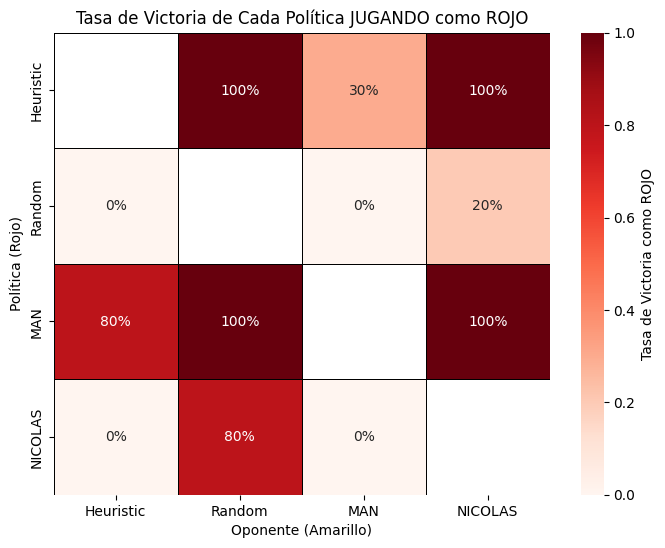

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# games=2, half_games=1
half_games = 200 // 2 
names = results_df["A"].unique() # Lista de nombres de las clases (e.g., 'MAN', 'GroupD', etc.)

# Crea una matriz inicial cuadrada de NaN con los nombres de las políticas
def initialize_pivot_table(names):
    pivot = pd.DataFrame(index=names, columns=names)
    np.fill_diagonal(pivot.values, np.nan) # NaN en la diagonal (A vs A)
    return pivot

## 1. Mapa de Calor: Victorias como ROJO (%)
pivot_rojo = initialize_pivot_table(names)

for index, row in results_df.iterrows():
    name_A = row["A"]
    name_B = row["B"]
    
    # Tasa de victoria de A como ROJO contra B
    winrate_A_rojo = row["A_red_wins"] / half_games
    pivot_rojo.loc[name_A, name_B] = winrate_A_rojo
    
    # Tasa de victoria de B como ROJO contra A
    winrate_B_rojo = row["B_red_wins"] / half_games
    pivot_rojo.loc[name_B, name_A] = winrate_B_rojo

plt.figure(figsize=(8, 6))
# APLICA LA CONVERSIÓN A FLOAT AQUÍ: .astype(float)
sns.heatmap(pivot_rojo.astype(float), annot=True, cmap="Reds", fmt=".0%",
            linewidths=.5, linecolor='black', vmin=0, vmax=1,
            cbar_kws={'label': 'Tasa de Victoria como ROJO'})
plt.title("Tasa de Victoria de Cada Política JUGANDO como ROJO")
plt.xlabel("Oponente (Amarillo)")
plt.ylabel("Política (Rojo)")
plt.savefig("mapa_calor_rojo.png")

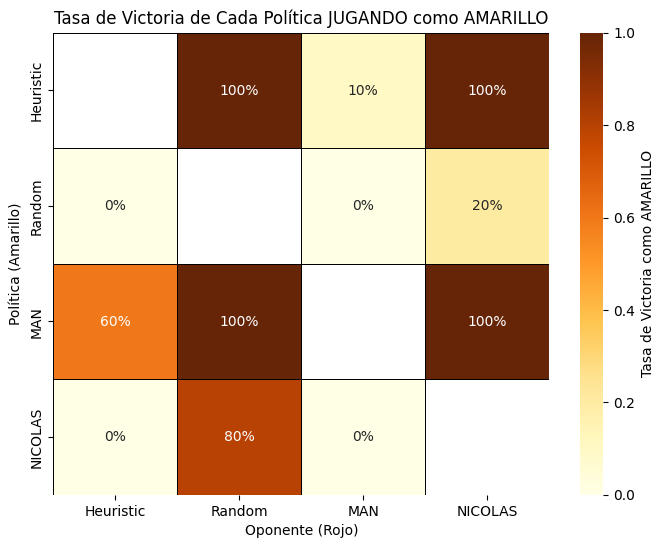

In [ ]:
## 2. Mapa de Calor: Victorias como AMARILLO (%)
pivot_amarillo = initialize_pivot_table(names)

for index, row in results_df.iterrows():
    name_A = row["A"]
    name_B = row["B"]
    
    # Tasa de victoria de A como AMARILLO contra B
    winrate_A_amarillo = row["A_yellow_wins"] / half_games
    pivot_amarillo.loc[name_A, name_B] = winrate_A_amarillo
    
    # Tasa de victoria de B como AMARILLO contra A
    winrate_B_amarillo = row["B_yellow_wins"] / half_games
    pivot_amarillo.loc[name_B, name_A] = winrate_B_amarillo

plt.figure(figsize=(8, 6))
# APLICA LA CONVERSIÓN A FLOAT AQUÍ: .astype(float)
sns.heatmap(pivot_amarillo.astype(float), annot=True, cmap="YlOrBr", fmt=".0%",
            linewidths=.5, linecolor='black', vmin=0, vmax=1,
            cbar_kws={'label': 'Tasa de Victoria como AMARILLO'})
plt.title("Tasa de Victoria de Cada Política JUGANDO como AMARILLO")
plt.xlabel("Oponente (Rojo)")
plt.ylabel("Política (Amarillo)")
plt.savefig("mapa_calor_amarillo.png")

In [ ]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from collections import Counter

from connect4.connect_state import ConnectState
from groups.GroupD.policy import MAN
from groups.GroupA.policy import MATEO as RawMATEO

In [ ]:
# ==========================
# CONFIGURACIÓN AJUSTABLE
# ==========================

OUTPUT_DIR="graficas_MAN"

EPISODIOS_CURVA=2          # episodios para curvas de victoria
PARTIDAS_DIST=2           # partidas para distribuciones de movimientos
PARTIDAS_ROLLOUTS=2        # partidas para recolectar rollouts
TIMEOUT_MAN=2             # time_out que se pasa a MANLAS.mount

BUDGETS_COMPARAR=[50,500,1000,10000]   # budgets para barra score
BUDGETS_MULTI=[50,500,1000,10000]          # budgets para gráfica multi-métrica

# ==========================
# ACTIVAR / DESACTIVAR GRÁFICAS
# ==========================

RUN_CURVAS = True
RUN_DISTRIBUCION = True
RUN_ROLLOUTS = True
RUN_BUDGETS = True
RUN_MULTI_BUDGET = True

In [ ]:
# ==========================
# HELPERS GENERALES
# ==========================

os.makedirs(OUTPUT_DIR,exist_ok=True)


def get_next_index():
    nums=[]
    for fname in os.listdir(OUTPUT_DIR):
        if fname.endswith(".png") or fname.endswith(".txt"):
            parte=fname.split("_",1)[0]
            if parte.isdigit():
                nums.append(int(parte))
    if nums:
        return max(nums)+1
    return 1


def partidas_por_budget(b):
    if b<=50:
        return 40
    elif b<=200:
        return 30
    elif b<=500:
        return 20
    elif b<=1000:
        return 10
    else:
        return 1

class SafeMATEO:
    def _init_(self):
        self.inner=RawMATEO()
    def mount(self,args,*kwargs):
        """Intenta llamar mount del agente MATEO con varias firmas posibles."""
        # 1) Intento directo con args/kwargs proporcionados
        try:
            return self.inner.mount(args,*kwargs)
        except TypeError:
            pass
        # 2) Intento con keyword time_out si la firma lo acepta
        try:
            return self.inner.mount(time_out=TIMEOUT_MAN)
        except TypeError:
            pass
        # 3) Intento con positional TIMEOUT_MAN
        try:
            return self.inner.mount(TIMEOUT_MAN)
        except TypeError:
            pass
        # 4) Último intento sin argumentos
        try:
            return self.inner.mount()
        except TypeError:
            raise TypeError("No se pudo montar MATEO con ninguna firma conocida.")
    def act(self,s):
        try:
            return int(self.inner.act(s))
        except Exception:
            s_arr=np.array(s)
            cols=[c for c in range(7) if s_arr[0,c]==0]
            if not cols:
                return 0
            return int(np.random.choice(cols))

In [ ]:
# ==========================
# SIMULACIÓN Y EVALUACIÓN
# ==========================

def jugar_partida(policy_red,policy_yellow):
    tablero=np.zeros((6,7),dtype=int)
    turno=-1
    state=ConnectState(tablero,player=turno)
    history=[]
    while not state.is_final():
        if turno==-1:
            a=policy_red.act(state.board)
            jugador=-1
        else:
            a=policy_yellow.act(state.board)
            jugador=1
        history.append((state.board.copy(),jugador,a))
        try:
            state=state.transition(a)
        except:
            return 0,history
        turno=state.player
    return state.get_winner(),history


def evaluar(policy_red,policy_yellow,n=50,quien="MAN_red",pos_counter=None):
    victorias=0
    empates=0
    movimientos_MAN=Counter()
    primeros_mov_MAN=Counter()
    longitudes=[]
    for i in range(n):
        w,hist=jugar_partida(policy_red,policy_yellow)
        longitudes.append(len(hist))
        if quien=="MAN_red":
            if w==-1:
                victorias+=1
        else:
            if w==1:
                victorias+=1
        if w==0:
            empates+=1
        MAN_color=-1 if quien=="MAN_red" else 1
        primer_registrado=False
        for s,jugador,a in hist:
            if jugador==MAN_color:
                movimientos_MAN[a]+=1
                if not primer_registrado:
                    primeros_mov_MAN[a]+=1
                    primer_registrado=True
                if pos_counter is not None:
                    fila=None
                    for r in range(6):
                        if s[r,a]==0:
                            fila=r
                            break
                    if fila is not None:
                        pos_counter[(fila,a)]+=1
        if (i+1)==1 or (i+1)==n or (i+1)%10==0:
            print(f"      Partida {i+1}/{n} ({quien})")
    winrate=victorias/n
    empate_rate=empates/n
    return winrate,empate_rate,movimientos_MAN,primeros_mov_MAN,np.array(longitudes)

In [ ]:
# ==========================
# GRÁFICAS ESPECÍFICAS
# ==========================

def curva_victoria_vs_mateo(episodios):
    print("[1/7] Curva de rendimiento MAN rojo vs MATEO...")
    man = MAN()
    man.mount(time_out=TIMEOUT_MAN)
    mateo = SafeMATEO()
    mateo.mount()
    resultados = []
    for i in range(episodios):
        w, _ = jugar_partida(man, mateo)
        if w == -1:
            resultados.append(1.0)
        elif w == 0:
            resultados.append(0.5)
        else:
            resultados.append(0.0)
        if (i+1) == 1 or (i+1) == episodios or (i+1) % 10 == 0:
            print(f"      Partida {i+1}/{episodios} (curva rojo)")
    resultados = np.array(resultados, dtype=float)
    score_acum = np.cumsum(resultados) / np.arange(1, len(resultados) + 1)
    plt.figure(figsize=(8,4))
    plt.plot(score_acum)
    plt.title("Curva de rendimiento de MAN vs MATEO (MAN rojo)")
    plt.xlabel("Partidas jugadas")
    plt.ylabel("Score medio (1 win, 0.5 empate, 0 derrota)")
    plt.grid(True)
    idx = get_next_index()
    fname = os.path.join(OUTPUT_DIR, f"{idx:03d}_curva_score_MAN_rojo_vs_mateo.png")
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:", fname)


def curva_victoria_vs_mateo_amarillo(episodios):
    print("[2/7] Curva de rendimiento MAN amarillo vs MATEO...")
    man = MAN()
    man.mount(time_out=TIMEOUT_MAN)
    mateo = SafeMATEO()
    mateo.mount()
    resultados = []
    for i in range(episodios):
        w, _ = jugar_partida(mateo, man)
        if w == 1:
            resultados.append(1.0)
        elif w == 0:
            resultados.append(0.5)
        else:
            resultados.append(0.0)
        if (i+1) == 1 or (i+1) == episodios or (i+1) % 10 == 0:
            print(f"      Partida {i+1}/{episodios} (curva amarillo)")
    resultados = np.array(resultados, dtype=float)
    score_acum = np.cumsum(resultados) / np.arange(1, len(resultados) + 1)
    plt.figure(figsize=(8,4))
    plt.plot(score_acum)
    plt.title("Curva de rendimiento de MAN vs MATEO (MAN amarillo)")
    plt.xlabel("Partidas jugadas")
    plt.ylabel("Score medio (1 win, 0.5 empate, 0 derrota)")
    plt.grid(True)
    idx = get_next_index()
    fname = os.path.join(OUTPUT_DIR, f"{idx:03d}_curva_score_MAN_amarillo_vs_mateo.png")
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:", fname)


def distribucion_movimientos_MAN(n_partidas, como_rojo=True):
    man = MAN()
    man.mount(time_out=TIMEOUT_MAN)
    mateo = SafeMATEO()
    mateo.mount()
    pos_counter = Counter()
    if como_rojo:
        print("[3/7] Distribución de movimientos MAN como ROJO...")
        wr, er, movs, prim, longs = evaluar(man, mateo, n=n_partidas, quien="MAN_red", pos_counter=pos_counter)
        sufijo = "rojo"
    else:
        print("[3/7] Distribución de movimientos MAN como AMARILLO...")
        wr, er, movs, prim, longs = evaluar(mateo, man, n=n_partidas, quien="MAN_yellow", pos_counter=pos_counter)
        sufijo = "amarillo"
    cols = sorted(movs.keys())
    freqs = [movs[c] for c in cols]
    plt.figure(figsize=(7,4))
    plt.bar(cols, freqs)
    plt.xticks(cols)
    plt.title("Distribución de columnas jugadas por MAN (" + sufijo + ")")
    plt.xlabel("Columna")
    plt.ylabel("Frecuencia")
    plt.grid(axis='y')
    idx = get_next_index()
    fname1 = os.path.join(OUTPUT_DIR, f"{idx:03d}_distribucion_movimientos_MAN_{sufijo}.png")
    plt.savefig(fname1, bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:", fname1)
    cols2 = sorted(prim.keys())
    freqs2 = [prim[c] for c in cols2]
    plt.figure(figsize=(7,4))
    plt.bar(cols2, freqs2, color='orange')
    plt.xticks(cols2)
    plt.title("Distribución de la PRIMERA jugada de MAN (" + sufijo + ")")
    plt.xlabel("Columna")
    plt.ylabel("Frecuencia")
    plt.grid(axis='y')
    idx = get_next_index()
    fname2 = os.path.join(OUTPUT_DIR, f"{idx:03d}_distribucion_primer_mov_MAN_{sufijo}.png")
    plt.savefig(fname2, bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:", fname2)
    idx = get_next_index()
    txtname = os.path.join(OUTPUT_DIR, f"{idx:03d}_posiciones_mas_jugadas_MAN_{sufijo}.txt")
    with open(txtname, "w") as f:
        f.write("Posiciones (fila,col) más jugadas por MAN (" + sufijo + ")\n")
        for (fila, col), cnt in pos_counter.most_common():
            f.write(f"({fila},{col}): {cnt}\n")
    print("    Guardado resumen posiciones en:", txtname)
    return wr, er, longs

In [ ]:
def grafica_longitudes(longs, descripcion):
    plt.figure(figsize=(7,4))
    bins = range(0,43,2)
    plt.hist(longs, bins=bins, edgecolor='black')
    plt.title("Distribución de longitudes de partidas (" + descripcion + ")")
    plt.xlabel("Número de movimientos")
    plt.ylabel("Frecuencia")
    plt.grid(axis='y')
    idx = get_next_index()
    base = "hist_longitudes_" + descripcion.replace(" ", "_").replace("/", "_")
    fname = os.path.join(OUTPUT_DIR, f"{idx:03d}_{base}.png")
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:", fname)
    print("    ", descripcion, " longitud media:", longs.mean(), " desvío estándar:", longs.std())


def grafica_rollouts(n_partidas):
    print("[4/7] Rollouts internos de MAN vs MATEO...")
    man = MAN()
    man.mount(time_out=TIMEOUT_MAN)
    mateo = SafeMATEO()
    mateo.mount()
    for i in range(n_partidas):
        jugar_partida(man, mateo)
        if (i+1) == 1 or (i+1) == n_partidas or (i+1) % 10 == 0:
            print(f"      Partida {i+1}/{n_partidas} (rollouts)")
    rewards = np.array(man.rollout_rewards)
    if len(rewards) == 0:
        print("    No hay rollouts registrados.")
        return
    vals, cnts = np.unique(rewards, return_counts=True)
    plt.figure(figsize=(6,4))
    plt.bar([str(v) for v in vals], cnts)
    plt.title("Histograma de recompensas en rollouts")
    plt.xlabel("Reward (−1,0,1)")
    plt.ylabel("Frecuencia")
    plt.grid(axis='y')
    idx = get_next_index()
    fname1 = os.path.join(OUTPUT_DIR, f"{idx:03d}_hist_rollouts_MAN.png")
    plt.savefig(fname1, bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:", fname1)
    media_acum = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
    plt.figure(figsize=(8,4))
    plt.plot(media_acum)
    plt.title("Media acumulada de reward en rollouts")
    plt.xlabel("Índice de simulación")
    plt.ylabel("Reward promedio")
    plt.grid(True)
    idx = get_next_index()
    fname2 = os.path.join(OUTPUT_DIR, f"{idx:03d}_media_acum_rollouts_MAN.png")
    plt.savefig(fname2, bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:", fname2)
    print("    Reward medio total en rollouts:", rewards.mean())

In [ ]:
def comparar_budgets_vs_mateo(budgets):
    print("[5/7] Comparando budgets de MCTS vs MATEO...")
    mateo=SafeMATEO()
    mateo.mount()
    scores_rojo=[]
    scores_amarillo=[]
    for idx_b,b in enumerate(budgets):
        n_part=partidas_por_budget(b)
        print(f"    Budget {b} ({idx_b+1}/{len(budgets)}) - MAN rojo, {n_part} partidas...")
        MAN_r=MAN()
        MAN_r.mount(time_out=TIMEOUT_MAN)
        MAN_r.budget=b
        wr_r,er_r,_,_,_=evaluar(MAN_r,mateo,n=n_part,quien="MAN_red")
        score_r=wr_r+0.5*er_r
        scores_rojo.append(score_r)
        print(f"      winrate rojo={wr_r:.3f}, empates={er_r:.3f}, score={score_r:.3f}")
        print(f"    Budget {b} ({idx_b+1}/{len(budgets)}) - MAN amarillo, {n_part} partidas...")
        MAN_y=MAN()
        MAN_y.mount(time_out=TIMEOUT_MAN)
        MAN_y.budget=b
        wr_y,er_y,_,_,_=evaluar(mateo,MAN_y,n=n_part,quien="MAN_yellow")
        score_y=wr_y+0.5*er_y
        scores_amarillo.append(score_y)
        print(f"      winrate amarillo={wr_y:.3f}, empates={er_y:.3f}, score={score_y:.3f}")
    x=np.arange(len(budgets))
    w=0.35
    plt.figure(figsize=(8,4))
    plt.bar(x-w/2,scores_rojo,width=w,label="MAN rojo")
    plt.bar(x+w/2,scores_amarillo,width=w,label="MAN amarillo")
    plt.xticks(x,[str(b) for b in budgets])
    plt.ylim(0,1)
    plt.title("Impacto de budget MCTS en score de MAN vs MATEO")
    plt.xlabel("budget (simulaciones por acción)")
    plt.ylabel("Score medio (1 win, 0.5 empate, 0 derrota)")
    plt.legend()
    plt.grid(axis='y')
    idx=get_next_index()
    fname=os.path.join(OUTPUT_DIR,f"{idx:03d}_budget_vs_score_MAN_vs_mateo.png")
    plt.savefig(fname,bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:",fname)

In [ ]:
def grafica_multi_budget(budgets):
    print("[6/7] Gráfica multi-métrica para budgets",budgets,"...")
    mateo=SafeMATEO()
    mateo.mount()
    score_r=[]
    score_y=[]
    roll_mean=[]
    for idx_b,b in enumerate(budgets):
        n_part=partidas_por_budget(b)
        print(f"    Budget {b} ({idx_b+1}/{len(budgets)}) con {n_part} partidas por color...")
        MAN_r=MAN()
        MAN_r.mount(time_out=TIMEOUT_MAN)
        MAN_r.budget=b
        wr_r,er_r,_,_,_=evaluar(MAN_r,mateo,n=n_part,quien="MAN_red")
        s_r=wr_r+0.5*er_r
        score_r.append(s_r)
        if len(MAN_r.rollout_rewards)>0:
            roll_mean.append(float(np.mean(MAN_r.rollout_rewards)))
        else:
            roll_mean.append(0.0)
        MAN_y=MAN()
        MAN_y.mount(time_out=TIMEOUT_MAN)
        MAN_y.budget=b
        wr_y,er_y,_,_,_=evaluar(mateo,MAN_y,n=n_part,quien="MAN_yellow")
        s_y=wr_y+0.5*er_y
        score_y.append(s_y)
        print(f"      score rojo={s_r:.3f}, score amarillo={s_y:.3f}, reward medio rollouts={roll_mean[-1]:.3f}")
    x=np.array(budgets,dtype=float)
    plt.figure(figsize=(8,4))
    plt.plot(x,score_r,"-o",label="Score MAN rojo")
    plt.plot(x,score_y,"-s",label="Score MAN amarillo")
    plt.plot(x,roll_mean,"-^",label="Reward medio rollouts (MAN rojo)")
    plt.xscale("log")
    plt.ylim(0,1)
    plt.title("Rendimiento de MAN según budget MCTS")
    plt.xlabel("Budget (simulaciones por acción, escala log)")
    plt.ylabel("Métrica (0–1)")
    plt.grid(True)
    plt.legend()
    idx=get_next_index()
    fname=os.path.join(OUTPUT_DIR,f"{idx:03d}_multi_metrica_budgets_MAN_vs_mateo.png")
    plt.savefig(fname,bbox_inches="tight")
    plt.show()
    plt.close()
    print("    Guardada:",fname)

In [ ]:
if __name__ == "__main__":
    print("Iniciando análisis de MAN vs MATEO...")

    if RUN_CURVAS:
        curva_victoria_vs_mateo(episodios=EPISODIOS_CURVA)
        curva_victoria_vs_mateo_amarillo(episodios=EPISODIOS_CURVA)

    if RUN_DISTRIBUCION:
        wr_r, er_r, longs_r = distribucion_movimientos_MAN(n_partidas=PARTIDAS_DIST, como_rojo=True)
        grafica_longitudes(longs_r, "MAN rojo vs MATEO")
        wr_y, er_y, longs_y = distribucion_movimientos_MAN(n_partidas=PARTIDAS_DIST, como_rojo=False)
        grafica_longitudes(longs_y, "MAN amarillo vs MATEO")

    if RUN_ROLLOUTS:
        grafica_rollouts(n_partidas=PARTIDAS_ROLLOUTS)

    if RUN_BUDGETS:
        comparar_budgets_vs_mateo(budgets=BUDGETS_COMPARAR)

    if RUN_MULTI_BUDGET:
        grafica_multi_budget(budgets=BUDGETS_MULTI)

    print("[7/7] Análisis completado. Archivos guardados en:", OUTPUT_DIR)